# Task 2 -- Exploratory Data Analysis

Global Geopolitical Event Prediction: Impact on USD Exchange Rates

This notebook explores the aligned dataset built in Task 1 and the daily feature
table built for Task 2. It covers:

1. The USD/IDR JISDOR series and the prediction target
2. News corpus composition, volume and coverage
3. The temporal alignment rule in practice
4. Sentiment and lexicon feature distributions
5. Relationships between news features and next-day direction

Every time-series chart is shaded by the chronological train / validation / test
split, because that split is the most important structural constraint on the
analysis.

In [1]:
import sys, warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config
import viz

viz.apply_style()
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 60)
print("project root:", ROOT)

project root: C:\Users\lenovo\Documents\codng\nlp-project


In [2]:
daily = pd.read_csv(config.DAILY_DATASET_CSV, parse_dates=["date"])
aligned = pd.read_csv(config.ALIGNED_ARTICLES_CSV, low_memory=False,
                      parse_dates=["query_date", "trading_day"])
rates = pd.read_csv(config.RATES_CLEAN_CSV, parse_dates=["date"])

print(f"daily feature table : {daily.shape[0]:,} trading days x {daily.shape[1]} cols")
print(f"aligned articles    : {len(aligned):,}")
print(f"JISDOR fixings      : {len(rates):,}")
print(f"window              : {daily.date.min().date()} -> {daily.date.max().date()}")

daily feature table : 1,202 trading days x 53 cols
aligned articles    : 53,843
JISDOR fixings      : 1,202
window              : 2021-09-01 -> 2026-09-01


## 1. The exchange rate series and the target

findfont: Failed to find font weight 600 for DejaVu Sans, now using 700.


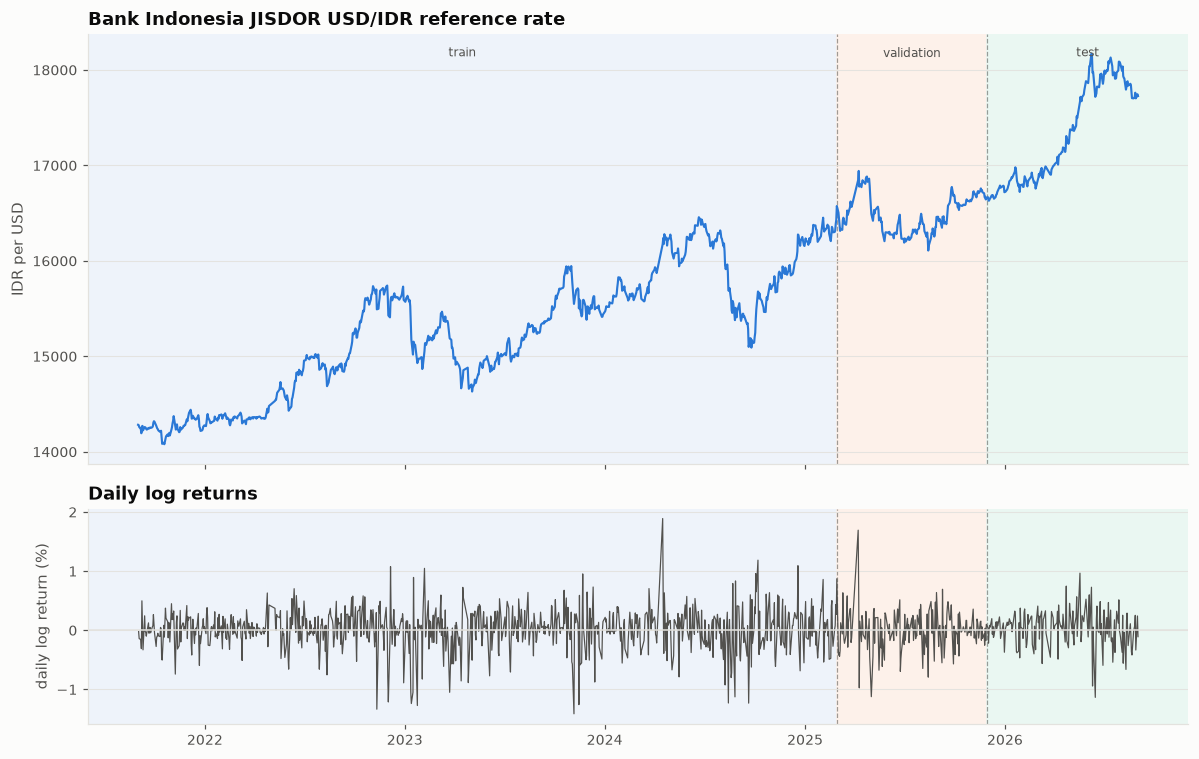

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})

ax = axes[0]
ax.plot(daily.date, daily.rate, color=viz.COLOR_RATE, lw=1.4)
ax.set_ylabel("IDR per USD")
ax.set_title("Bank Indonesia JISDOR USD/IDR reference rate")
viz.shade_splits(ax, pd.Timestamp(config.TRAIN_END), pd.Timestamp(config.VAL_END))

ax = axes[1]
ax.plot(daily.date, daily.log_return * 100, color=viz.TEXT_SECONDARY, lw=0.8)
ax.axhline(0, color=viz.GRID, lw=1)
ax.set_ylabel("daily log return (%)")
ax.set_title("Daily log returns")
viz.shade_splits(ax, pd.Timestamp(config.TRAIN_END), pd.Timestamp(config.VAL_END),
                 label=False)

plt.tight_layout()
plt.show()

In [4]:
# The rupiah depreciated steadily across the window, so the UP class dominates.
# That base rate is what every model has to be judged against.
print("Target: 1 = USD strengthens against IDR (rate rises)")
print(f"overall UP rate : {daily.direction.mean():.3f}")
for name, end in [("train", config.TRAIN_END), ("validation", config.VAL_END)]:
    pass

blocks = {
    "train":      daily[daily.date.dt.date <= config.TRAIN_END],
    "validation": daily[(daily.date.dt.date > config.TRAIN_END)
                        & (daily.date.dt.date <= config.VAL_END)],
    "test":       daily[daily.date.dt.date > config.VAL_END],
}
summary = pd.DataFrame({
    name: {
        "days": len(b),
        "UP rate": b.direction.mean(),
        "mean |return| %": (b.log_return.abs() * 100).mean(),
        "return std %": (b.log_return * 100).std(),
    }
    for name, b in blocks.items()
}).T
summary.round(4)

Target: 1 = USD strengthens against IDR (rate rises)
overall UP rate : 0.553


,days,UP rate,mean |return| %,return std %
train,849.0,0.5559,0.2480,0.3421
validation,177.0,0.5141,0.2413,0.3318
test,176.0,0.5795,0.2226,0.2918


The UP rate differs between blocks (train 0.56, validation 0.51, test 0.58). This
is a real property of the period, not a splitting error, and it is exactly why
accuracy alone is a misleading metric here: a constant "UP" predictor scores
differently on each block. Macro-F1 and MCC are reported alongside accuracy for
this reason.

## 2. News corpus composition

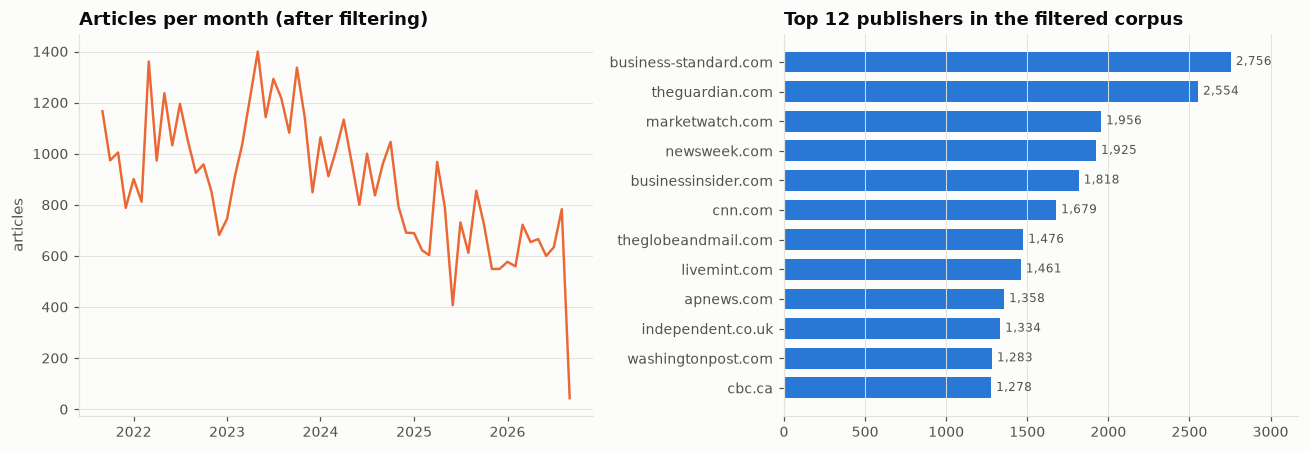

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# Left: monthly article volume -- one series, so no legend needed.
monthly = (aligned.set_index("trading_day")
                  .resample("MS").size().rename("articles").reset_index())
axes[0].plot(monthly.trading_day, monthly.articles, color=viz.COLOR_NEWS, lw=1.6)
axes[0].set_title("Articles per month (after filtering)")
axes[0].set_ylabel("articles")
axes[0].tick_params(axis="x", rotation=0)

# Right: top publishers -- horizontal bars, direct-labelled.
top = aligned.domain.value_counts().head(12).sort_values()
bars = axes[1].barh(top.index, top.values, color=viz.COLOR_RATE, height=0.7)
axes[1].set_title("Top 12 publishers in the filtered corpus")
axes[1].grid(axis="x", visible=True)
axes[1].grid(axis="y", visible=False)
for bar, val in zip(bars, top.values):
    axes[1].text(val + 30, bar.get_y() + bar.get_height() / 2, f"{val:,}",
                 va="center", fontsize=8, color=viz.TEXT_SECONDARY)
axes[1].set_xlim(0, top.values.max() * 1.15)

plt.tight_layout()
plt.show()

In [6]:
per_day = aligned.groupby("trading_day").size()
print(f"trading days with news : {len(per_day):,} / {len(rates):,} "
      f"({100*len(per_day)/len(rates):.1f}%)")
print(f"articles per trading day: mean {per_day.mean():.1f}, "
      f"median {per_day.median():.0f}, min {per_day.min()}, max {per_day.max()}")
print(f"distinct publishers     : {aligned.domain.nunique()}")

trading days with news : 1,190 / 1,202 (99.0%)
articles per trading day: mean 45.2, median 39, min 4, max 433
distinct publishers     : 76


## 3. The temporal alignment rule in practice

Every article is attached to the first trading day **strictly after** its
publication date, because the GDELT snapshot is sampled at 12:00 UTC (19:00 WIB)
— after Bank Indonesia has already published that day's fixing at ~10:00 WIB.

The lag histogram below is a direct check that the rule behaves as intended:
weekday news lands on the next session (+1 day), while Friday and weekend news
accumulates onto Monday (+2 to +3 days). Longer lags are Indonesian public
holidays.

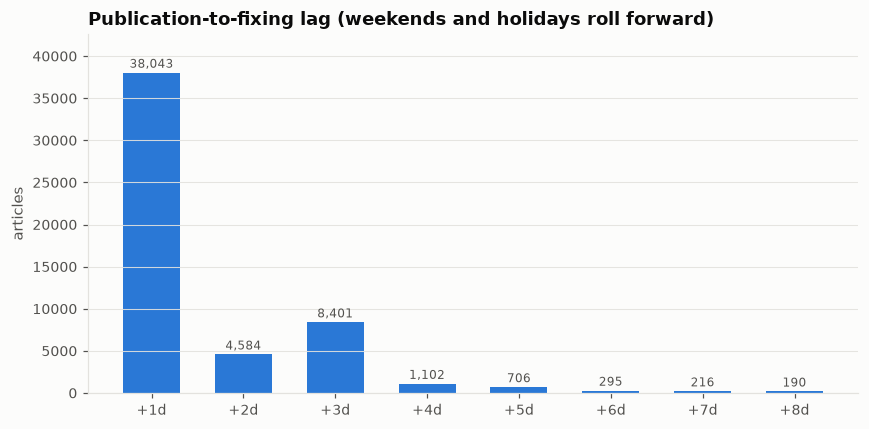

articles by publication weekday:
dow
Monday       8436
Tuesday      9353
Wednesday    9444
Thursday     9858
Friday       8840
Saturday     3840
Sunday       4072


In [7]:
lag = (aligned.trading_day - aligned.query_date).dt.days
counts = lag.value_counts().sort_index()
counts = counts[counts.index <= 8]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar([f"+{d}d" for d in counts.index], counts.values,
              color=viz.COLOR_RATE, width=0.62)
ax.set_title("Publication-to-fixing lag (weekends and holidays roll forward)")
ax.set_ylabel("articles")
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + counts.values.max() * 0.015,
            f"{val:,}", ha="center", fontsize=8, color=viz.TEXT_SECONDARY)
ax.set_ylim(0, counts.values.max() * 1.12)
plt.tight_layout()
plt.show()

wd = aligned.assign(dow=aligned.query_date.dt.day_name()).groupby("dow").size()
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
print("articles by publication weekday:")
print(wd.reindex(order).to_string())

## 4. Sentiment and lexicon feature distributions

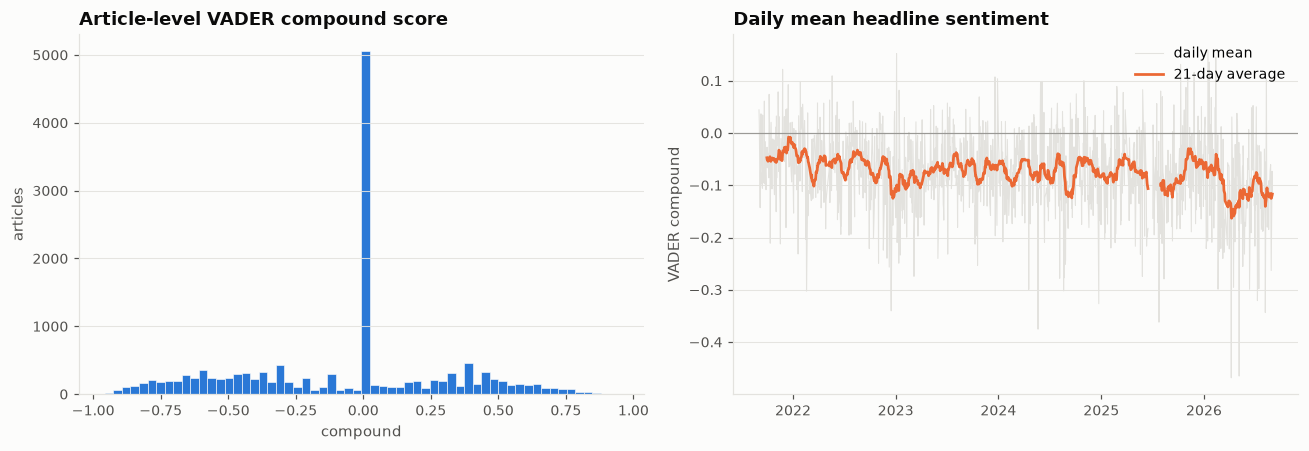

share of headlines scored negative : 0.381
share scored positive              : 0.271
share scored neutral               : 0.347


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# Article-level VADER compound distribution.
import features as feat
art = aligned.sample(min(15000, len(aligned)), random_state=0).copy()
scored = feat.score_articles(art)

axes[0].hist(scored.vader_compound, bins=60, color=viz.COLOR_RATE,
             edgecolor=viz.SURFACE, linewidth=0.4)
axes[0].set_title("Article-level VADER compound score")
axes[0].set_xlabel("compound")
axes[0].set_ylabel("articles")

# Daily mean sentiment over time, with a rolling trend for legibility.
axes[1].plot(daily.date, daily.vader_mean, color=viz.GRID, lw=0.7,
             label="daily mean")
axes[1].plot(daily.date, daily.vader_mean.rolling(21).mean(),
             color=viz.COLOR_NEWS, lw=1.8, label="21-day average")
axes[1].axhline(0, color=viz.TEXT_SECONDARY, lw=0.8, alpha=0.5)
axes[1].set_title("Daily mean headline sentiment")
axes[1].set_ylabel("VADER compound")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

print(f"share of headlines scored negative : {(scored.vader_compound < -0.05).mean():.3f}")
print(f"share scored positive              : {(scored.vader_compound >  0.05).mean():.3f}")
print(f"share scored neutral               : {(scored.vader_compound.abs() <= 0.05).mean():.3f}")

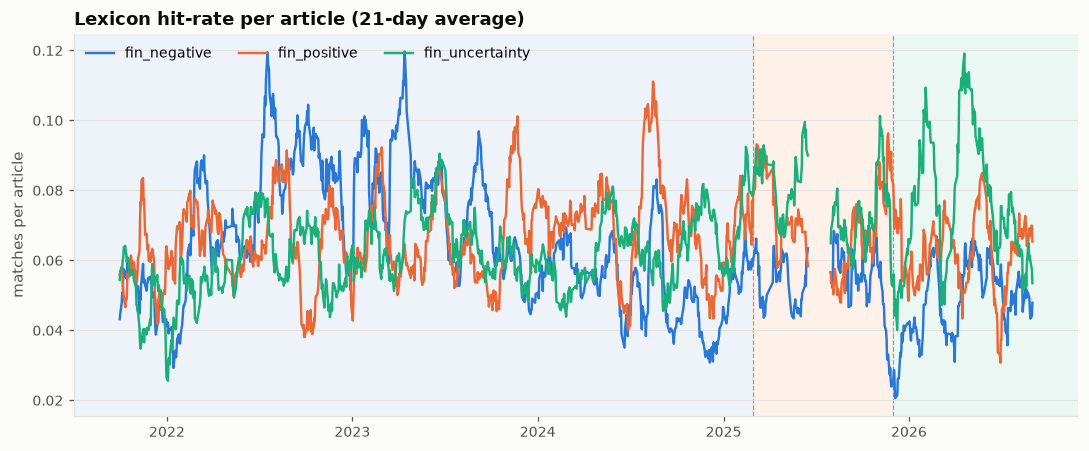

,count,mean,std,min,25%,50%,75%,max
fin_negative_rate,1190.0,0.061,0.051,0.0,0.026,0.053,0.088,0.429
fin_positive_rate,1190.0,0.066,0.053,0.0,0.029,0.057,0.095,0.391
fin_uncertainty_rate,1190.0,0.066,0.047,0.0,0.031,0.062,0.091,0.375
fin_constraining_rate,1190.0,0.028,0.039,0.0,0.000,0.020,0.041,0.367
geo_risk_rate,1190.0,0.121,0.083,0.0,0.065,0.104,0.163,0.733
monetary_rate,1190.0,0.095,0.083,0.0,0.038,0.077,0.132,0.646


In [9]:
lex_cols = [c for c in daily.columns if c.endswith("_rate")
            and c.startswith(("fin_", "geo_", "monetary"))]

fig, ax = plt.subplots(figsize=(10, 4.2))
for i, col in enumerate(lex_cols[:3]):
    ax.plot(daily.date, daily[col].rolling(21).mean(),
            color=viz.CATEGORICAL[i], lw=1.6, label=col.replace("_rate", ""))
ax.set_title("Lexicon hit-rate per article (21-day average)")
ax.set_ylabel("matches per article")
ax.legend(loc="upper left", ncols=3)
viz.shade_splits(ax, pd.Timestamp(config.TRAIN_END), pd.Timestamp(config.VAL_END),
                 label=False)
plt.tight_layout()
plt.show()

daily[lex_cols].describe().T.round(3)

## 5. Do news features relate to next-day direction?

The honest way to look at this before modelling is the point-biserial
correlation between each feature and the binary target, computed on the
**training block only** — inspecting this on the test block would be a form of
manual leakage.

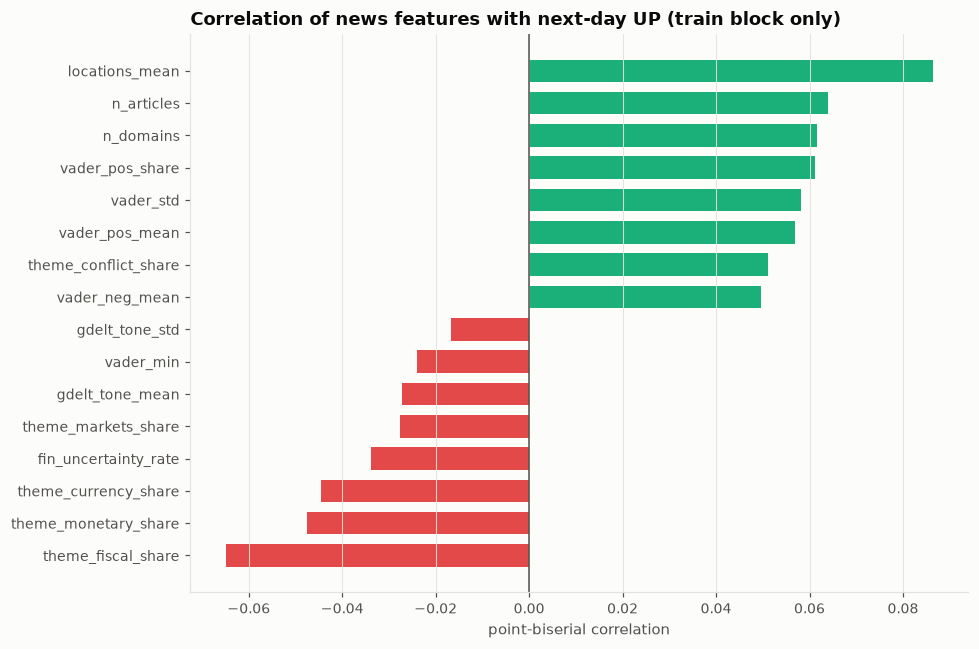

strongest absolute correlation: 0.0864


In [10]:
train = daily[daily.date.dt.date <= config.TRAIN_END].copy()

news_cols = [c for c in daily.columns
             if c.startswith(("vader_", "fin_", "theme_", "gdelt_tone"))
             or c in ("n_articles", "n_domains", "persons_mean",
                      "orgs_mean", "locations_mean")]

corr = (train[news_cols]
        .apply(lambda s: s.corr(train["direction"]))
        .dropna()
        .sort_values())

top = pd.concat([corr.head(8), corr.tail(8)])
colors = [viz.COLOR_DOWN if v < 0 else viz.COLOR_UP for v in top.values]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top.index, top.values, color=colors, height=0.7)
ax.axvline(0, color=viz.TEXT_SECONDARY, lw=1)
ax.set_title("Correlation of news features with next-day UP (train block only)")
ax.set_xlabel("point-biserial correlation")
ax.grid(axis="x", visible=True)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

print(f"strongest absolute correlation: {corr.abs().max():.4f}")

### Reading this chart

The correlations are all very small — the strongest is well under 0.1. That is
the expected result for daily FX direction and is the single most important
finding of the EDA: **any predictive signal from news is weak**, so the
modelling in `02_baseline_results.ipynb` should be read with the majority-class
baseline firmly in view, and small accuracy differences should not be
over-interpreted.